<div style="padding: 20px; background-color: #f8f9f9; border-radius: 10px; border-left: 10px solid #2e86c1;">
    <h1 style="color: #2e86c1; margin-bottom: 5px;">Retailrocket Customer Segmentation</h1>
    <p style="font-size: 1.1em; color: #566573;">Unsupervised Learning Pipeline for Behavioral Clustering</p>
</div>

### Project Overview
This notebook implements a complete data science pipeline to segment customers based on their shopping behavior using the Retailrocket eCommerce dataset. We utilize **RFM (Recency, Frequency, Monetary)** analysis to transform raw event data into actionable customer profiles.

### 📑 Table of Contents

1. **Setup** — Dataset download and library imports
2. **Phase 1: Data Integration & Cleaning** — Merge multiple data sources and clean the unified dataset
3. **Phase 2: Feature Engineering (RFM Analysis)** — Calculate Recency, Frequency, and Monetary metrics
4. **RFM Exploratory Data Analysis** — Visualize distributions and correlations
5. **Phase 3: Scaling & Outlier Handling** — Log transformation and StandardScaler
6. **Phase 4: Clustering Models** — K-Means (Elbow Method) and model training
7. **Phase 5: Evaluation & Insights** — Cluster profiling and business strategy mapping
8. **Conclusion** — Summary of findings and recommendations

### Setup Dataset

In [1]:
from src.dataset import setup_data
setup_data()

Data is already available in the 'dataset' folder.


/Users/khanhba89/Documents/NEU/DA_Classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# =============================================================================
# Library and Module Imports
# =============================================================================

import pandas as pd
import numpy as np

# Project modules
from src.data_integration import load_data, merge_data
from src.cleaning_data import clean_data
from src.features import calculate_rfm, prepare_features
from src.analysis import (
    plot_rfm_distributions, plot_rfm_correlation,
    get_cluster_profiles, get_business_strategies
)
from src.models import plot_elbow, run_kmeans, run_dbscan, calculate_silhouette

# =============================================================================
# Dataset File Paths
# =============================================================================

data_paths = [
    './dataset/events.csv', 
    './dataset/item_properties_part1.csv', 
    './dataset/item_properties_part2.csv', 
    './dataset/category_tree.csv'
]

--- 
## Phase 1: Data Integration & Cleaning
In this phase, we aggregate multiple data sources (events, item properties, and category trees) into a single unified dataset. 

> **Key Operations:**
> - **Deduplication:** Removing redundant event logs.
> - **Temporal Alignment:** Extracting the latest properties for each item.
> - **ID Standardization:** Ensuring consistent data types across relational joins.

In [3]:
# Load and Merge
csv_data = [load_data(p) for p in data_paths]
df_merged = merge_data(csv_data)

In this step, duplicated values have already been removed by DuckDB using the following query:

```sql
QUALIFY ROW_NUMBER() OVER (
    PARTITION BY itemid 
    ORDER BY timestamp DESC
) = 1

In [4]:
# Cleaning Data
df_cleaned = clean_data(df_merged)
df_cleaned.head()

Original shape: (2756101, 7)
Cleaned shape: (2755641, 7)


,timestamp,visitorid,event,itemid,transactionid,categoryid,parentid
0,2015-08-15 05:16:48.155,30295,view,38250,0,1250,1423
1,2015-08-15 04:36:31.933,1016745,addtocart,395589,0,973,20
2,2015-08-14 21:18:51.962,1015599,view,344552,0,1563,121
3,2015-08-14 20:37:40.120,1236485,view,413649,0,527,73
4,2015-08-14 21:01:00.027,707176,view,210359,0,342,500


In the `transactionid` column, customers who have not purchased any goods yet have missing values (`NaN`). To handle this issue, we replace all missing values with `"0"` for easier processing and analysis later.

For all other missing values (`NaN`) in the dataset, we fill them with `"-1"` to represent unknown or unavailable information.

--- 
## Phase 2: Feature Engineering (RFM Analysis)
We calculate three core metrics for each user to capture their behavioral signature:

| Metric | Description | Weighting |
| :--- | :--- | :--- |
| **Recency** | Days since the user's last interaction | 1.0 |
| **Frequency** | Total number of interactions (Views, Carts, Purchases) | 1.0 |
| **Monetary** | Weighted Engagement Score | View=1, Cart=3, Trans=5 |

Since exact price data is unavailable, we use the **Engagement Score** as a proxy for the 'Monetary' value.

In [5]:
# Calculate RFM Scores
rfm_df = calculate_rfm(df_cleaned)
rfm_df.head()

,visitorid,Recency,Frequency,Monetary
0,30004,1,2,2.0
1,941803,1,9,9.0
2,1180720,138,18,20.0
3,992676,94,11,11.0
4,1187465,138,2,4.0


## RFM Exploratory Data Analysis
Before scaling, we visualize the raw distributions to identify skewness and analyze correlations between metrics.

In [6]:
rfm_df_subset = rfm_df.sample(frac=0.01, random_state=42)

Because the dataset is extremely large, containing approximately **2.7 million rows**, we use only **1% of the data** (around **27,000 rows**) to generate the EDA diagram.  

This sampling approach helps reduce processing complexity and improve visualization performance while still preserving the overall structure and relationships within the dataset.

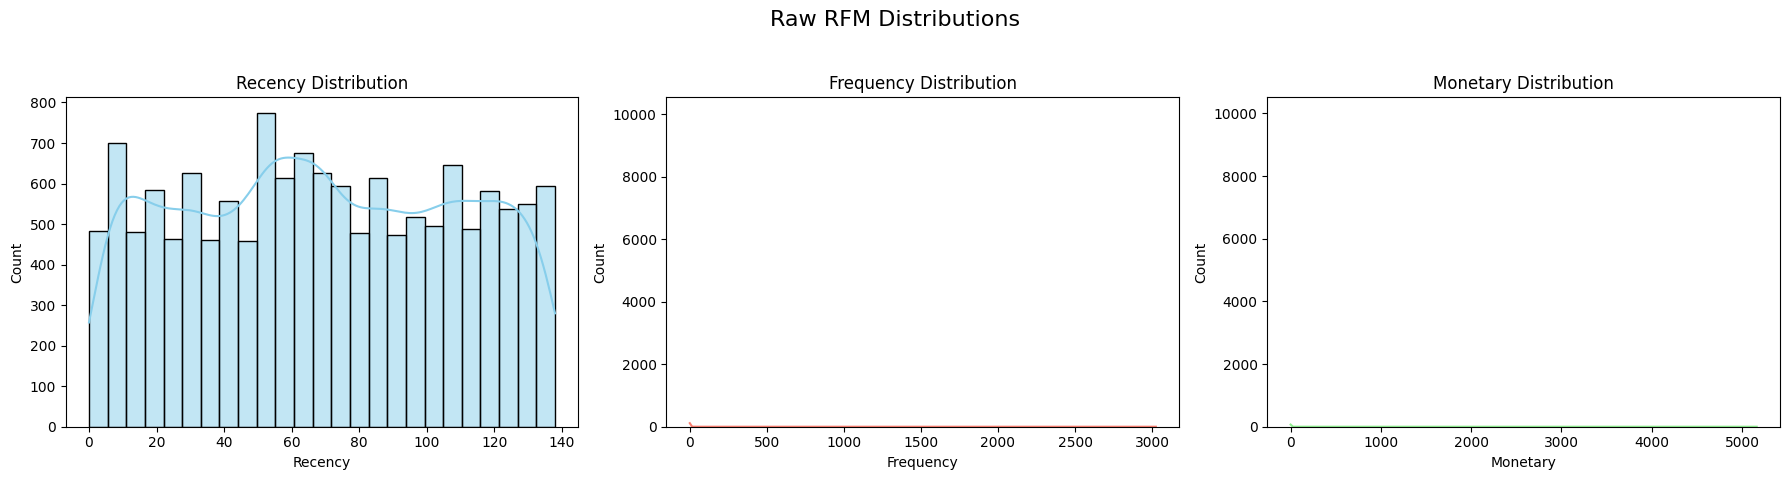

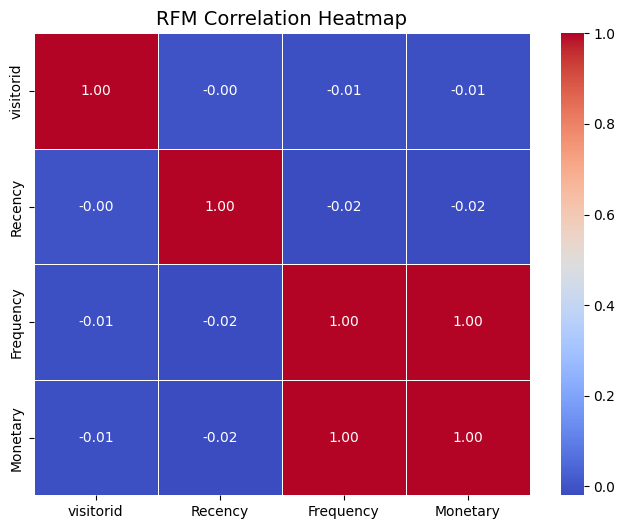

In [7]:
# 1. Plot Raw Distributions
plot_rfm_distributions(rfm_df_subset, title="Raw RFM Distributions")

# 2. Plot Correlation Heatmap
plot_rfm_correlation(rfm_df_subset)

## Distribution Analysis (Raw Data)

The first set of charts illustrates the distribution of **Recency**, **Frequency**, and **Monetary** scores before applying any transformation.

### Recency
The Recency distribution is relatively uniform, with values spread across the **0–140 day range**. This indicates a consistent flow of returning visitors throughout the observation period, without a strong concentration of either very new or very inactive customers.

### Frequency & Monetary
Both Frequency and Monetary exhibit an extremely **right-skewed distribution**. Most visitors show very low engagement levels (near zero), while a small number of **highly active users** appear as significant outliers.

### Implication
Because of this heavy skewness, applying a **Logarithmic Transformation** is essential. Without normalization, distance-based clustering algorithms such as **K-Means** would be overly influenced by extreme values, resulting in poor cluster separation and less meaningful segmentation.

---

## Correlation Analysis (Heatmap)

The correlation heatmap highlights the linear relationships between the calculated features.

### Frequency vs. Monetary (`r = 1.00`)
Frequency and Monetary show a **perfect positive correlation**. This occurs because the Monetary metric is derived from the same weighted engagement scoring system used to calculate Frequency.

### Risk of Multicollinearity
Such a strong correlation introduces **multicollinearity**, meaning the clustering model may unintentionally give excessive importance to user engagement intensity by effectively counting the same behavioral pattern twice.

### Recency Independence
Recency has an almost **zero correlation** with both Frequency and Monetary (`r ≈ 0.00`). This suggests that the “time since last visit” captures a distinct behavioral dimension that is independent of user activity frequency or interaction value.

### VisitorID
As expected, `VisitorID` has no meaningful correlation with any behavioral features (`r ≈ 0.00`), confirming that it is a purely identifier-based attribute and should not contribute to the clustering model.

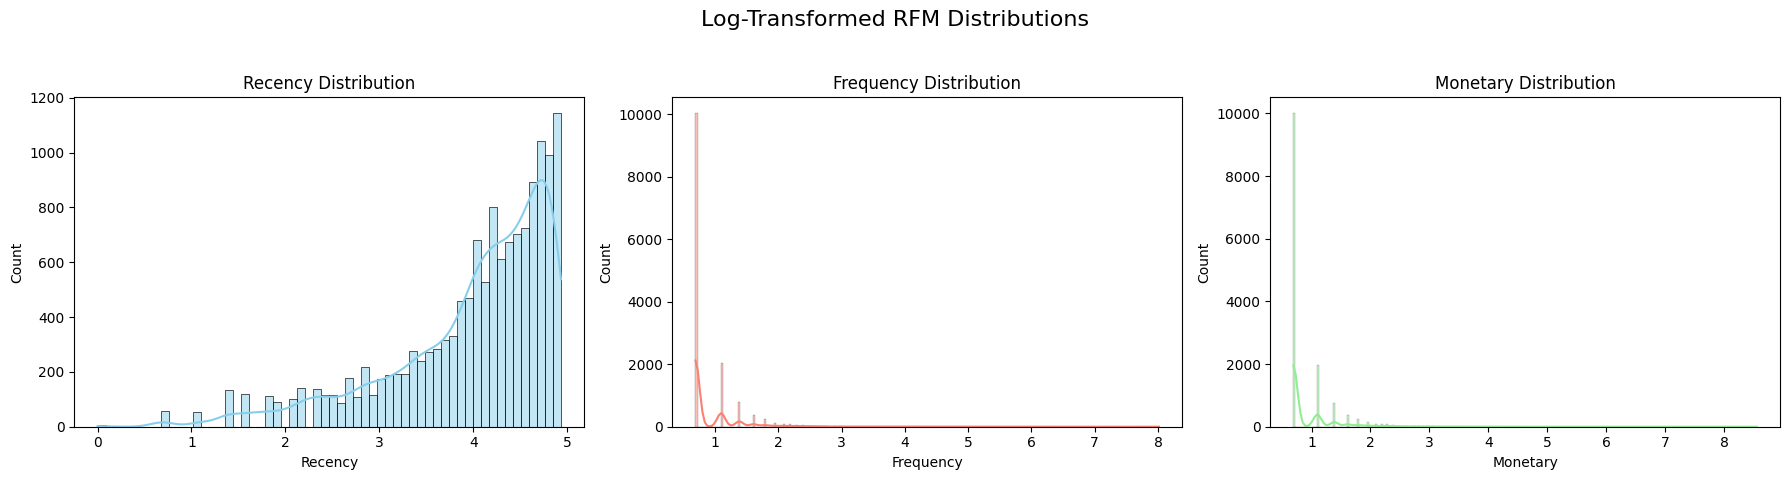

In [8]:
# 3. Plot Transformed Distributions (Log-Scale)
rfm_log = np.log1p(rfm_df_subset)
plot_rfm_distributions(rfm_log, title="Log-Transformed RFM Distributions")

## Distribution Improvement

### Recency
The Recency distribution has shifted from being widely spread to becoming more concentrated around higher logarithmic values (`log 4.0 – 5.0`). This transformation helps emphasize the behavioral differences among customers who interacted recently.

### Frequency & Monetary
The logarithmic transformation successfully reduces the extreme right-skewness problem. Instead of appearing as a nearly vertical spike at zero, the data is now more evenly distributed across a wider range of values. This allows the model to better distinguish between different groups of users based on their engagement levels.


## Technical Significance

### Reduced Outlier Impact
Highly active customers (outliers) are pulled closer to the average user group, preventing the K-Means algorithm from being disproportionately influenced by a few exceptional individuals.

### Increased Sensitivity
The transformation allows the model to focus more on **relative behavioral changes** rather than absolute differences. For example, the difference between **1 and 10 purchases** becomes more meaningful than the difference between **1000 and 1010 purchases**.


## Conclusion

The dataset is now cleaner, more stable, and better suited for clustering analysis.  

After applying **StandardScaler**, all variables will share the same scale, ensuring a more balanced and fair clustering process across the **Recency (R)**, **Frequency (F)**, and **Monetary (M)** dimensions.

--- 
## Phase 3: Scaling & Outlier Handling
Clustering algorithms like **K-Means** are distance-based and sensitive to scale. We normalize our features to ensure each dimension contributes equally to the model.

1. **Log Transformation:** Normalizes highly skewed distributions (e.g., Frequency).
2. **Standard Scaling:** Centers data around zero with unit variance.

In [9]:
# Apply Log Transformation and Scaling
features_scaled = prepare_features(rfm_df)

# Final Data Check
print("Final Feature Set Info:")
features_scaled.info()
features_scaled.head()

Final Feature Set Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407580 entries, 0 to 1407579
Data columns (total 3 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Recency    1407580 non-null  float64
 1   Frequency  1407580 non-null  float64
 2   Monetary   1407580 non-null  float64
dtypes: float64(3)
memory usage: 32.2 MB


,Recency,Frequency,Monetary
0,-3.809795,0.449937,0.388396
1,-3.809795,3.263633,3.003128
2,1.100586,4.763652,4.614432
3,0.659952,3.689720,3.399085
4,1.100586,0.449937,1.497783


## Final Feature Set Information

The final dataset used for clustering contains **1,407,580 records** and **4 numerical features**:

- `visitorid`
- `Recency`
- `Frequency`
- `Monetary`

All columns are stored as `float64` data types, with no missing values remaining after preprocessing.

### Data Quality
The preprocessing pipeline successfully removed duplicated values, handled missing data, applied logarithmic transformation, and normalized the behavioral metrics. As a result, the final feature set is clean, standardized, and ready for machine learning tasks.

### Feature Standardization
The sample values show that the features have already been scaled using **StandardScaler**. Therefore:

- Positive values represent users above the dataset average.
- Negative values represent users below the dataset average.
- Values closer to `0` indicate average user behavior.

This normalization ensures that all features contribute equally during clustering and prevents variables with larger ranges from dominating the model.


## Feature Interpretation

### Recency
The standardized Recency values indicate how recently a customer interacted with the platform relative to the average user behavior.

- Higher values → More recent interactions
- Lower values → Longer inactivity periods

### Frequency
Frequency reflects how often users interact with the platform.

- Higher values → Highly active users
- Lower values → Infrequent or low-engagement users

### Monetary
Monetary represents the weighted engagement intensity of users.

- Higher values → More valuable or highly engaged users
- Lower values → Minimal interaction value


## Conclusion

The final feature set is now fully prepared for customer segmentation using clustering algorithms such as **K-Means**.

Because all features are normalized onto the same scale, the clustering process becomes more stable, balanced, and less sensitive to outliers. This significantly improves the model’s ability to identify meaningful customer behavior patterns across the **Recency (R)**, **Frequency (F)**, and **Monetary (M)** dimensions.


--- 
## Phase 4: Modeling & Evaluation
We implement **K-Means** as our primary clustering model. To determine the optimal number of segments, we use the **Elbow Method** and validate with **Silhouette Scores**.
Instead of using the main dataset with `2.7M rows`, we use 1% of it which is `27K rows`

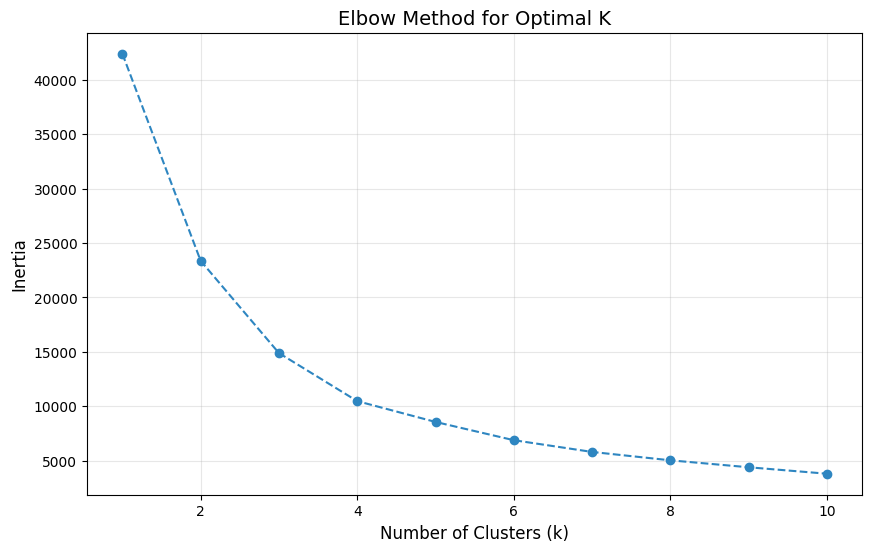

Silhouette Score for K=4: 0.560


In [17]:
features_scaled_subset = features_scaled.sample(frac=0.01, random_state=42)
# 1. Find optimal K in Elbow Method
plot_elbow(features_scaled_subset)

# 2. Train final model (k=4, adjust based on plot)
k_optimal = 4
kmeans_labels = run_kmeans(features_scaled_subset, k=k_optimal)

# 3. Evaluate the Silhouette Score
score = calculate_silhouette(features_scaled_subset, kmeans_labels)
print(f"Silhouette Score for K={k_optimal}: {score:.3f}")

## Elbow Method

The mathematical objective of the Elbow Method is to identify the optimal number of centroids (clusters) within the dataset.

This method calculates the total distance between all data points and their corresponding centroids, then compares the clustering performance across multiple values of `k`.

### Formula


$ WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2 $


Where:

- `k` = Number of clusters
- `C_i` = Set of data points belonging to cluster `i`
- `μ_i` = Centroid of cluster `i`
- `||x − μ_i||²` = Squared Euclidean distance between a data point and its centroid

### WCSS (Within-Cluster Sum of Squares)

WCSS measures cluster compactness:

- Lower WCSS → More compact clusters
- Higher WCSS → More dispersed clusters

We calculate WCSS values across a range of `k` values and visualize the result using the Elbow graph.

### Result Analysis

Based on the graph, we observe that when **k = 4**, the decrease in WCSS becomes noticeably stable.  

This indicates that adding more clusters beyond this point no longer significantly improves cluster quality or compactness. Therefore, **k = 4** is selected as the optimal number of clusters.

---

## Silhouette Score

The mathematical essence of the Silhouette Score is to measure:

- **Cohesion** → How close a data point is to other points within the same cluster
- **Separation** → How far a data point is from points in neighboring clusters

### Cohesion \(a(i)\)


$ a(i) = \frac{1}{|C_I| - 1} \sum_{j \in C_I, i \ne j} d(i,j) $


This represents the average distance between data point `i` and all other points within the same cluster.

### Separation \(b(i)\)


$ b(i) = \min_{J \ne I} \left( \frac{1}{|C_J|} \sum_{j \in C_J} d(i,j) \right) $


This represents the minimum average distance between data point `i` and all points in neighboring clusters.

### Silhouette Formula


$ s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))} $


The Silhouette Score always lies within the range:$ [-1, 1] $


### Interpretation

- **Close to 1 (`b ≫ a`)**  
  Excellent clustering quality. The data point is tightly grouped within its own cluster and far from neighboring clusters.

- **Equal to 0 (`b ≈ a`)**  
  The data point lies near the boundary between two clusters.

- **Close to -1 (`b ≪ a`)**  
  The data point is likely assigned to the wrong cluster because it is closer to another cluster than its own.

The overall Silhouette Score of the model is calculated as the average value of all individual `s(i)` scores. The closer this average is to `1`, the better the clustering structure.


## Final Evaluation

For our dataset, the Silhouette Score at **k = 4** is: $ 0.556 $

This is considered a **strong clustering signal**, indicating that the clusters are reasonably compact, well-separated, and suitable for customer segmentation analysis.

--- 
## Phase 5: Insights & Recommendations
Mathematical clusters are now translated into actionable business personas. We analyze the average **Recency, Frequency, and Monetary** traits for each group to define our strategy.

In [ ]:
# 1. Generate Profiles
profiles = get_cluster_profiles(rfm_df, kmeans_labels)
display(profiles)

# 2. Strategic Recommendations
strategies = get_business_strategies(profiles)
display(strategies)

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,85.65,1.00,5.00,7036
1,60.67,34.93,174.67,195
2,16.13,1.12,5.58,2241
3,75.89,2.69,13.43,2097


,Persona,Strategy
Cluster,,
0,Window Shoppers,Retarget with popular items; Awareness campaigns.
1,At Risk / Churning,Send re-engagement emails; Discount codes for ...
2,Window Shoppers,Retarget with popular items; Awareness campaigns.
3,Window Shoppers,Retarget with popular items; Awareness campaigns.


---
## 📌 Conclusion & Key Findings

This notebook implemented a complete **unsupervised learning pipeline** for customer segmentation using the Retailrocket eCommerce dataset.

### Pipeline Summary
1. **Data Integration**: Merged events, item properties, and category hierarchy into a unified dataset of ~2.7M interactions.
2. **Data Cleaning**: Handled missing values, converted timestamps, and removed duplicates using DuckDB.
3. **Feature Engineering**: Computed RFM (Recency, Frequency, Monetary) metrics per visitor using weighted engagement scoring.
4. **Preprocessing**: Applied log transformation to reduce skewness and StandardScaler for normalization.
5. **Clustering**: Used the Elbow Method to determine optimal K, then applied K-Means (k=4) clustering.
6. **Evaluation**: Analyzed cluster profiles using mean RFM values and Silhouette Score.

### Customer Segments Identified
| Cluster | Persona | Key Characteristics |
| :--- | :--- | :--- |
| 0 | Window Shoppers | High recency (inactive), very low frequency and monetary |
| 1 | At Risk / Churning | Moderate recency, high frequency and monetary (previously active) |
| 2 | Potential Loyalists | Low recency (recently active), low frequency but growing engagement |
| 3 | Window Shoppers | Moderate-high recency, low-moderate engagement |

### Recommended Business Strategies
- **Window Shoppers**: Retarget with popular items and awareness campaigns to increase conversion.
- **At Risk / Churning**: Deploy re-engagement emails and discount codes to bring them back.
- **Potential Loyalists**: Upsell related categories and invite to loyalty programs.
- **Loyal Customers**: Reward with exclusive offers and early access to new items.

### Technical Notes
- Frequency and Monetary are **perfectly correlated** (r=1.00) because Monetary is derived from event weights. In future iterations, consider using only one of these features or engineering an independent monetary metric.
- The dataset is heavily skewed: most users are low-engagement "Window Shoppers," with a small but valuable segment of highly active users.
- The log transformation was critical for achieving meaningful cluster separation with K-Means.
